In [1]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from core.models.advanced_deature_encoder import (
    MAEResNet, 
)
from core.custom_datasets.pokemon_dataset import PokemonDataset
from core.models.utils import prepare_vae, get_number_of_parameters
from core.image_utils import show_batch_grid

import os

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda:0"
IMG_SIZE = 128

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


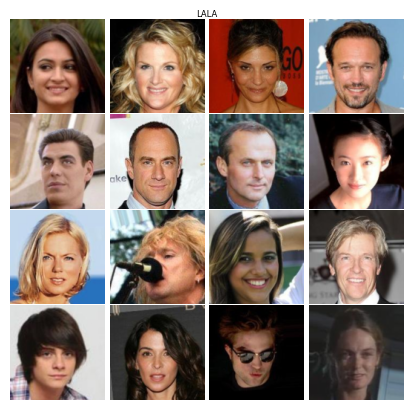

In [6]:
dataloader = DataLoader(pokemon_dataset, batch_size=16, shuffle=True, num_workers=8)

batch = next(iter(dataloader))
# show_batch_grid(batch, n=4, figsize=(5, 5), denormalize=True)
show_batch_grid(batch, n=4, figsize=(4, 4), denormalize=True, title="LALA")

# batch_reco = vae(batch.cuda().to(torch.bfloat16))
# show_batch_grid(batch, n=4, figsize=(7, 7), denormalize=True)

In [4]:
raise

RuntimeError: No active exception to reraise

In [ ]:
vae_name = "flux-vae"

vae_kwargs = {
    "device_map": "cuda:0",
    "torch_dtype": torch.bfloat16,
}

vae, latent_shape = prepare_vae(
    vae_name="flux_vae",
    path_to_vae="./checkpoints/flux_vae",
    img_size=IMG_SIZE,
    vae_kwargs=vae_kwargs
)

print("VAE:")
get_number_of_parameters(vae)

# vae = torch.compile(vae, mode="reduce-overhead")

VAE:
Params: 84M


In [ ]:
MASK_RATIO = 0.5

mae_resnet = MAEResNet(
        in_channels = latent_shape[0],
        base_channels = 256,
        mask_patch_size = 2,
        input_patch_size = 1,
        layers = (3, 4, 6, 3),
    ).to(torch.bfloat16).cuda()

print("mae_resnet:")
print("Encoder:")
get_number_of_parameters(mae_resnet.encoder)
print("Decoder:")
get_number_of_parameters(mae_resnet.decoder)

opt = torch.optim.AdamW(
    mae_resnet.parameters(), 
    lr=2e-4,
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

mae_resnet = torch.compile(mae_resnet, mode="reduce-overhead")

mae_resnet:
Encoder:
Params: 340M
Decoder:
Params: 89.1M


In [ ]:
batch_size = 128
# gradient_accumulation = 4
dataloader = DataLoader(pokemon_dataset, batch_size=batch_size, shuffle=True, num_workers=8)

In [ ]:
n_epochs = 100
plot_every = 100
save_step = 2500
save_path = f"/home/msst/repo/drifting/checkpoints/CelebA/MAE_{vae_name}_{mae_resnet.base_channels}/"


steps_per_epoch = len(dataloader)

loss_history = []
plot_loss_acc = []
for e in range(n_epochs):
    for step, batch in enumerate(tqdm(dataloader)):
        global_step = e * steps_per_epoch + step + 1
        
        batch = batch.cuda()
        with torch.no_grad():
            batch_latent = vae.encode(batch).latent_dist.sample()


        loss = mae_resnet(batch_latent, mask_ratio=MASK_RATIO)[0]
        loss.backward()
        # if step % gradient_accumulation == 0:
        opt.step()
        opt.zero_grad()
        
        plot_loss_acc.append(loss.item())
        
        
        if (global_step % plot_every == 0) or (global_step == 10):
            loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
            plot_loss_acc = []
            clear_output(wait=True)
            plt.plot(loss_history)
            with torch.no_grad():
                test_imgs = next(iter(dataloader))[:8].cuda()
                show_batch_grid(test_imgs, n=8, figsize=(9, 9), denormalize=True)

                test_imgs_latent = vae.encode(test_imgs).latent_dist.sample()
                mask = mae_resnet.make_patch_mask(test_imgs_latent, MASK_RATIO, 2)
                test_imgs_latent_masked = test_imgs_latent * (1.0 - mask)
                test_imgs_masked = vae.decode(test_imgs_latent_masked).sample
                show_batch_grid(test_imgs_masked, n=8, figsize=(9, 9), denormalize=True)

                feats_latent = mae_resnet.encoder(test_imgs_latent_masked)
                recon_latent = mae_resnet.decoder(feats_latent)
                # recon_latent = recon_latent * mask + test_imgs_latent_masked
                recon = vae.decode(recon_latent).sample
                show_batch_grid(recon, n=8, figsize=(9, 9), denormalize=True)
                plt.show()
    
    # if (global_step+1) % save_step == 0:
    os.makedirs(save_path, exist_ok=True)
    torch.save(mae_resnet.state_dict(), f"{save_path}/epochs{e}.pth")


  0%|          | 0/1583 [00:00<?, ?it/s]Exception ignored in: <function _afterFork at 0x70d87c9bbce0>
Traceback (most recent call last):
  File "/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/logging/__init__.py", line 245, in _afterFork
    def _afterFork():
KeyboardInterrupt: 
  0%|          | 0/1583 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 40341) exited unexpectedly